<a href="https://colab.research.google.com/github/Felipe2456/Aula-db/blob/main/lat%C3%AAncia_de_serializa%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Executando experimento de performance RESTful (JSON vs XML)...

--- TABELA 1: RESULTADOS DO EXPERIMENTO ---
 Registros  JSON_Total (ms)  XML_Total (ms)  Eficiência JSON (%)
        10           0.0684          0.2248                69.57
       100           0.2239          1.0526                78.73
      1000           2.0227         10.2644                80.29
     10000          19.7120        166.9662                88.19
     50000         104.5425        763.1607                86.30


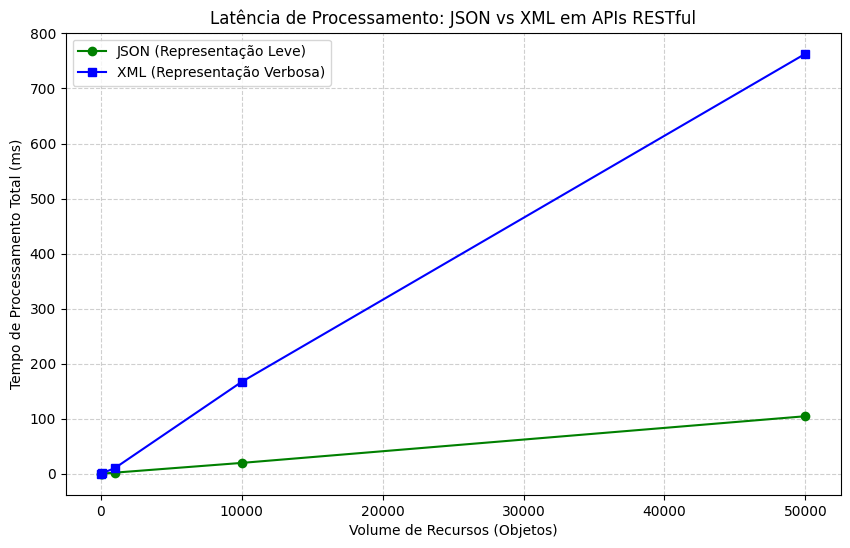


Experimento concluído. 'grafico.png' salvo com sucesso para o Zenodo.


In [2]:
import json
import xml.etree.ElementTree as ET
import time
import pandas as pd
import matplotlib.pyplot as plt
import random

def generate_mock_data(count):
    """Gera dados de produtos similares à classe ProdutosResource do livro."""
    return [{"id": i, "descricao": f"Produto_{i}", "valor": round(random.uniform(10, 1000), 2)} for i in range(count)]

def test_json_performance(data):
    # Serialização
    start = time.time()
    json_string = json.dumps(data)
    serialize_time = (time.time() - start) * 1000

    # Desserialização
    start = time.time()
    _ = json.loads(json_string)
    deserialize_time = (time.time() - start) * 1000

    return serialize_time, deserialize_time

def test_xml_performance(data):
    # Serialização (Construção manual da árvore XML conforme anotações @Produces)
    start = time.time()
    root = ET.Element("listagem")
    for item in data:
        prod = ET.SubElement(root, "produto")
        for key, val in item.items():
            child = ET.SubElement(prod, key)
            child.text = str(val)
    xml_string = ET.tostring(root, encoding='unicode')
    serialize_time = (time.time() - start) * 1000

    # Desserialização
    start = time.time()
    _ = ET.fromstring(xml_string)
    deserialize_time = (time.time() - start) * 1000

    return serialize_time, deserialize_time

def run_experiment():
    sample_sizes = [10, 100, 1000, 10000, 50000]
    results = []

    print("Executando experimento de performance RESTful (JSON vs XML)...")

    for size in sample_sizes:
        data = generate_mock_data(size)
        j_ser, j_des = test_json_performance(data)
        x_ser, x_des = test_xml_performance(data)

        results.append({
            "Registros": size,
            "JSON_Total (ms)": round(j_ser + j_des, 4),
            "XML_Total (ms)": round(x_ser + x_des, 4),
            "Eficiência JSON (%)": round((((x_ser + x_des) - (j_ser + j_des)) / (x_ser + x_des)) * 100, 2)
        })

    # Exibição dos dados em Tabela
    df = pd.DataFrame(results)
    print("\n--- TABELA 1: RESULTADOS DO EXPERIMENTO ---")
    print(df.to_string(index=False))

    # Geração do Gráfico
    plt.figure(figsize=(10, 6))
    plt.plot(df["Registros"], df["JSON_Total (ms)"], marker='o', label='JSON (Representação Leve)', color='green')
    plt.plot(df["Registros"], df["XML_Total (ms)"], marker='s', label='XML (Representação Verbosa)', color='blue')

    plt.title("Latência de Processamento: JSON vs XML em APIs RESTful")
    plt.xlabel("Volume de Recursos (Objetos)")
    plt.ylabel("Tempo de Processamento Total (ms)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # Salvamento para o Artigo
    plt.savefig('grafico.png')
    plt.show()
    print("\nExperimento concluído. 'grafico.png' salvo com sucesso para o Zenodo.")

if __name__ == "__main__":
    run_experiment()